In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
from ASM_utils import AdaptiveSmoothing
import warnings 
import os
import random
warnings.filterwarnings("ignore")

device = torch.device("cpu")
speed = np.load('../data/processed_data/rds/lane1/2024-07-09.npy')
motion = np.load('../data/processed_data/motion/lane1/2024-07-09.npy')
space_size, time_size = speed.shape
speed = torch.tensor(speed, dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # Add batch and channel dimensions
best_model_path = '../logs/calibration/20250607_203336/best_model_lane1.pt'

print('speed shape:', speed.shape)
dx = 0.02                  # distance per cell
dt = 4.0                    # time per cell
kernel_time_window = time_size * dt  # seconds
kernel_space_window = space_size * dx  # same units as dx

speed shape: torch.Size([1, 1, 200, 3600])


In [2]:
# load the best model
best_model_path = '../model/20250607_221107/best_model_lane1.pt'
calibrated_model = torch.load(best_model_path, map_location=device)
model = AdaptiveSmoothing(kernel_time_window,
                          kernel_space_window,
                          dx, dt,
                          init_tau=calibrated_model['tau'],
                          init_delta=calibrated_model['delta'],
                          init_c_cong=calibrated_model['c_cong']).to(device)

model.eval()

AdaptiveSmoothing()

In [3]:
with torch.no_grad():
    smoothed = model(speed)

In [4]:
sm = smoothed[0].cpu().numpy()

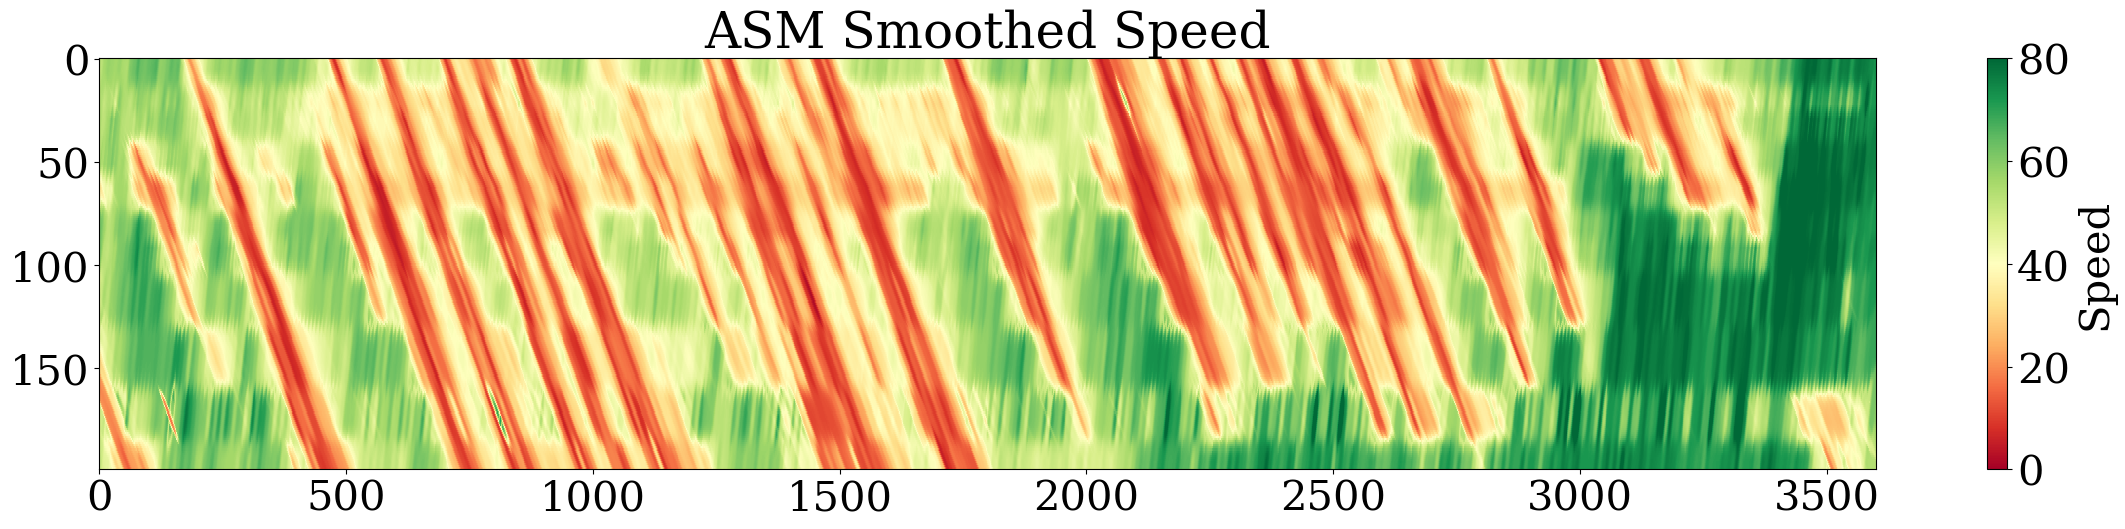

In [5]:
plt.figure(figsize=(24, 6))
plt.rcParams.update({'font.size': 30, 'font.family': 'serif'})
plt.imshow(sm, cmap='RdYlGn', interpolation='nearest', origin='lower',vmin=0, vmax=80, aspect='auto')
plt.colorbar(label='Speed')
plt.title('ASM Smoothed Speed')
plt.tight_layout()
# reverse the y-axis    
plt.gca().invert_yaxis()
plt.show()

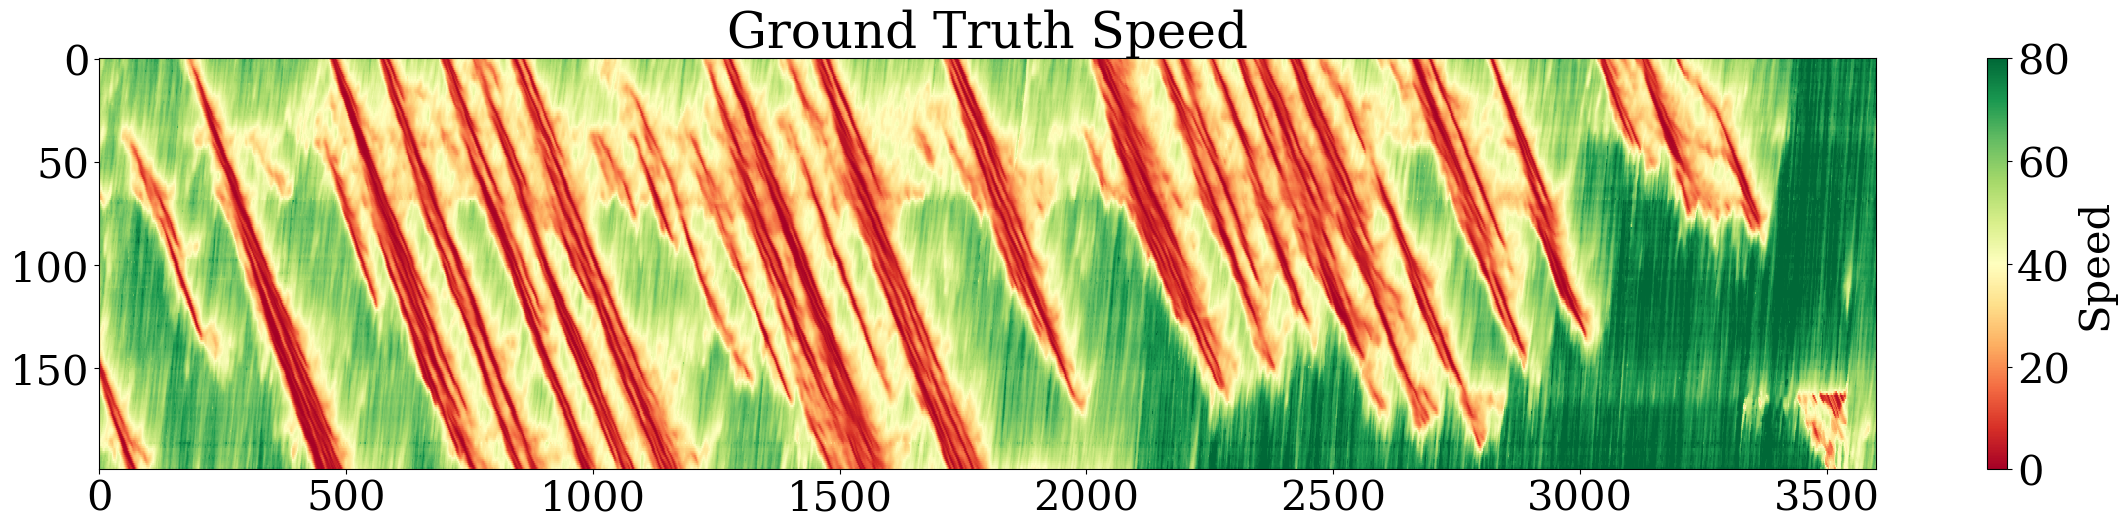

In [6]:
plt.figure(figsize=(24, 6))
plt.rcParams.update({'font.size': 30, 'font.family': 'serif'})
plt.imshow(motion, cmap='RdYlGn', interpolation='nearest', origin='lower',vmin=0, vmax=80, aspect='auto')
plt.colorbar(label='Speed')
plt.title('Ground Truth Speed')
plt.tight_layout()
# reverse the y-axis    
plt.gca().invert_yaxis()
plt.show()

In [7]:
# get the countor of a matrix 
import torch
import numpy as np
import matplotlib.pyplot as plt
def get_contour(matrix, threshold=30.0):
    """
    Get the contour of a matrix based on a threshold.
    
    Args:
        matrix (np.ndarray): The input matrix.
        threshold (float): The threshold value to determine the contour.
        
    Returns:
        np.ndarray: A binary matrix representing the contour.
    """
    binary_matrix = (matrix <= threshold).astype(int)
    return binary_matrix

# caculate the IoU of two contours for two matrices
def calculate_iou(matrix1, matrix2):
    """
    Calculate the Intersection over Union (IoU) of two matrices,
    plus counts of elements unique to each.
    
    Args:
        matrix1 (np.ndarray): The first binary matrix.
        matrix2 (np.ndarray): The second binary matrix.
        
    Returns:
        tuple: (iou, only_in_1, only_in_2)
    """
    contour1 = get_contour(matrix1)
    contour2 = get_contour(matrix2)

    intersection = np.logical_and(contour1, contour2).sum()
    union = np.logical_or(contour1, contour2).sum()

    # return the intersection matrix as well
    intersection_matrix = np.logical_and(contour1, contour2).astype(int)
    only_in_1_matrix = np.logical_and(contour1, np.logical_not(contour2)).astype(int)
    only_in_2_matrix = np.logical_and(contour2, np.logical_not(contour1)).astype(int)
    iou = intersection / union if union != 0 else 0.0
    only1 = only_in_1_matrix.sum()/union if union != 0 else 0.0
    only2 = only_in_2_matrix.sum()/union if union != 0 else 0.0
    iou = round(iou, 4)
    only1 = round(only1, 4)
    only2 = round(only2, 4)
    return iou, only1, only2, intersection_matrix, only_in_1_matrix, only_in_2_matrix

IoU: 0.7871


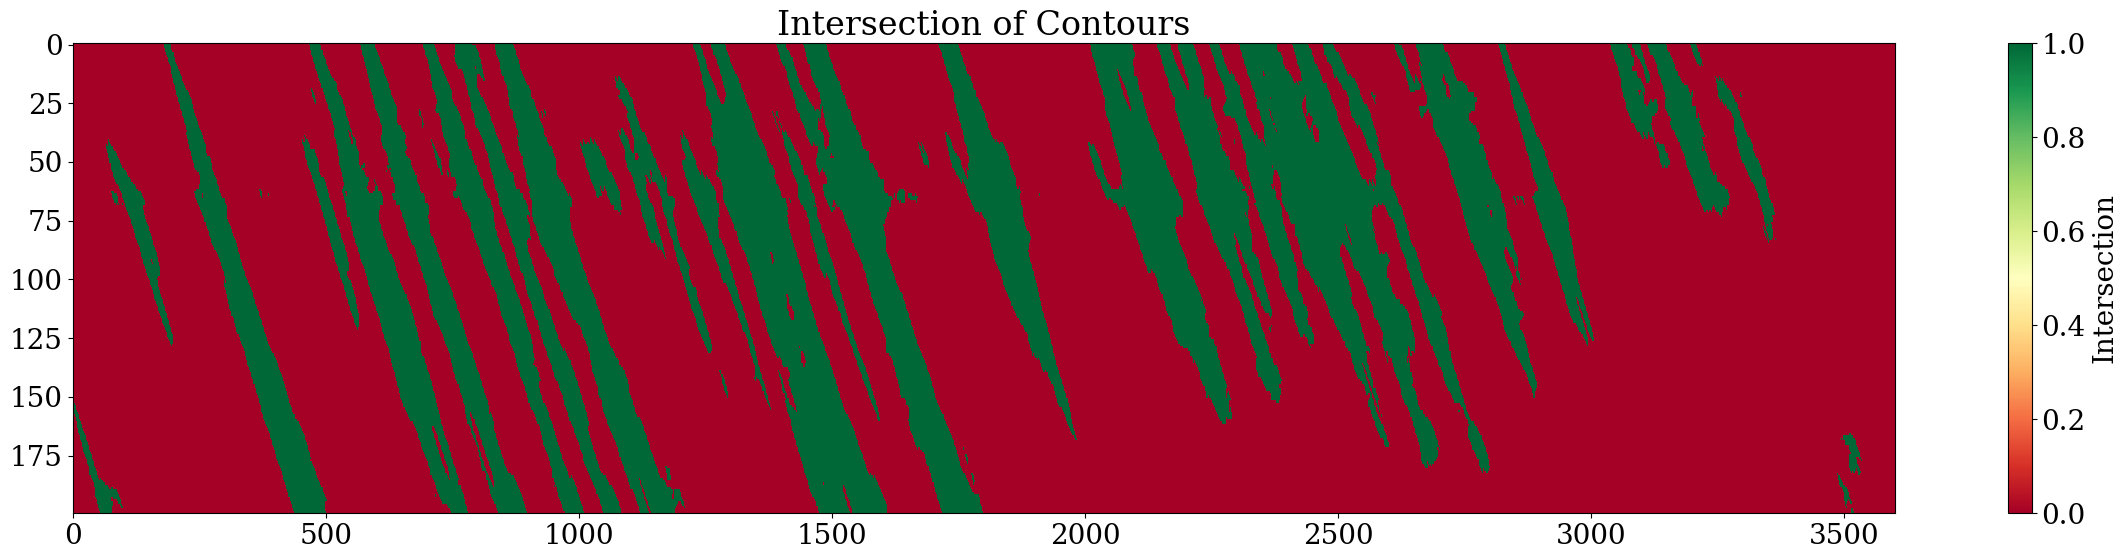

In [8]:
iou, only1, only2, intersection_matrix, only_in_sm, only_in_motion = calculate_iou(sm, motion)
print(f"IoU: {iou}")
plt.figure(figsize=(24, 6))
plt.rcParams.update({'font.size': 20, 'font.family': 'serif'})
plt.imshow(intersection_matrix, cmap='RdYlGn', interpolation='nearest', origin='lower', vmin=0, vmax=1, aspect='auto')
plt.colorbar(label='Intersection')
plt.title('Intersection of Contours')
plt.tight_layout()
# reverse the y-axis
plt.gca().invert_yaxis()

In [9]:
print(f"Only in smoothed: {only1}")
print(f"Only in motion: {only2}")
print(f"iou: {iou}")

Only in smoothed: 0.1016
Only in motion: 0.1113
iou: 0.7871


IoU: 0.7871


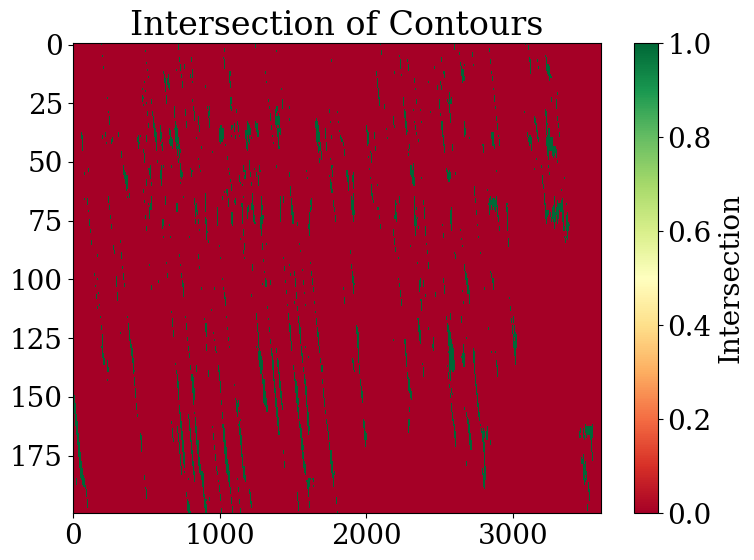

In [10]:
iou, only1, only2, intersection_matrix, only_in_1_matrix, only_in_2_matrix = calculate_iou(sm, motion)
print(f"IoU: {iou}")
plt.figure(figsize=(8, 6))
plt.rcParams.update({'font.size': 20, 'font.family': 'serif'})
plt.imshow(only_in_motion, cmap='RdYlGn', interpolation='nearest', origin='lower', vmin=0, vmax=1, aspect='auto')
plt.colorbar(label='Intersection')
plt.title('Intersection of Contours')
plt.tight_layout()
# reverse the y-axis
plt.gca().invert_yaxis()

IoU: 0.7871


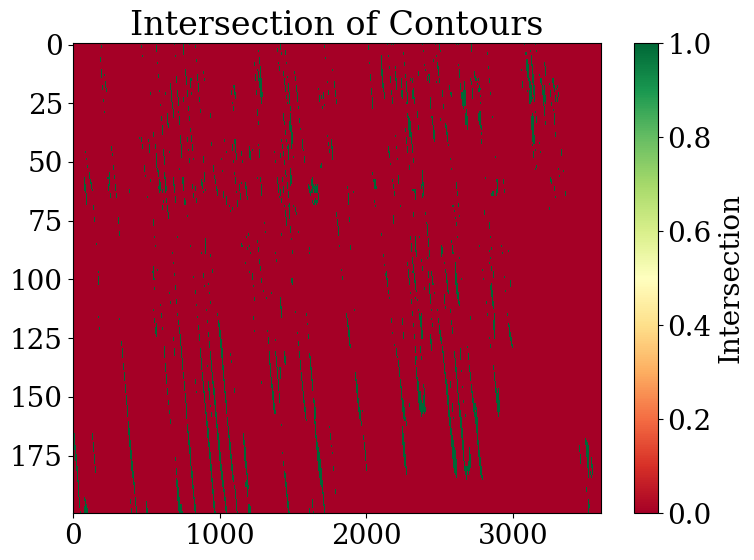

In [11]:
iou, only1, only2, intersection_matrix, only_in_1_matrix, only_in_2_matrix = calculate_iou(sm, motion)
print(f"IoU: {iou}")
plt.figure(figsize=(8, 6))
plt.rcParams.update({'font.size': 20, 'font.family': 'serif'})
plt.imshow(only_in_sm, cmap='RdYlGn', interpolation='nearest', origin='lower', vmin=0, vmax=1, aspect='auto')
plt.colorbar(label='Intersection')
plt.title('Intersection of Contours')
plt.tight_layout()
# reverse the y-axis
plt.gca().invert_yaxis()

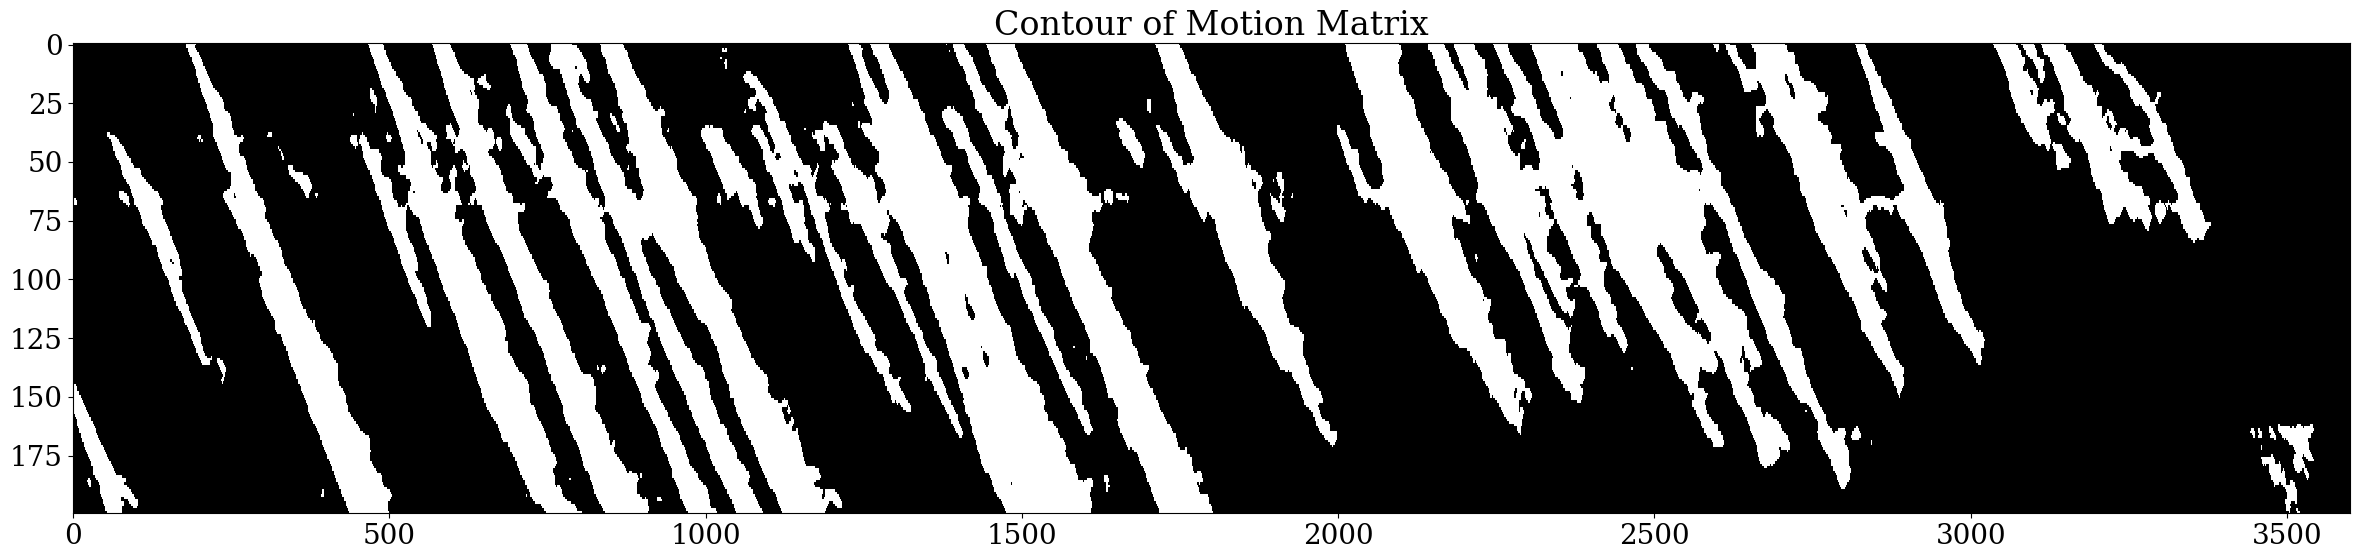

In [12]:
# visualize the contour of the matrix of motion
motion_contour = get_contour(motion,30)
plt.figure(figsize=(24, 6))
plt.rcParams.update({'font.size': 20, 'font.family': 'serif'})
plt.imshow(motion_contour, cmap='gray', interpolation='nearest', origin='lower', aspect='auto')
plt.title('Contour of Motion Matrix')
plt.tight_layout()
plt.gca().invert_yaxis()
plt.show()

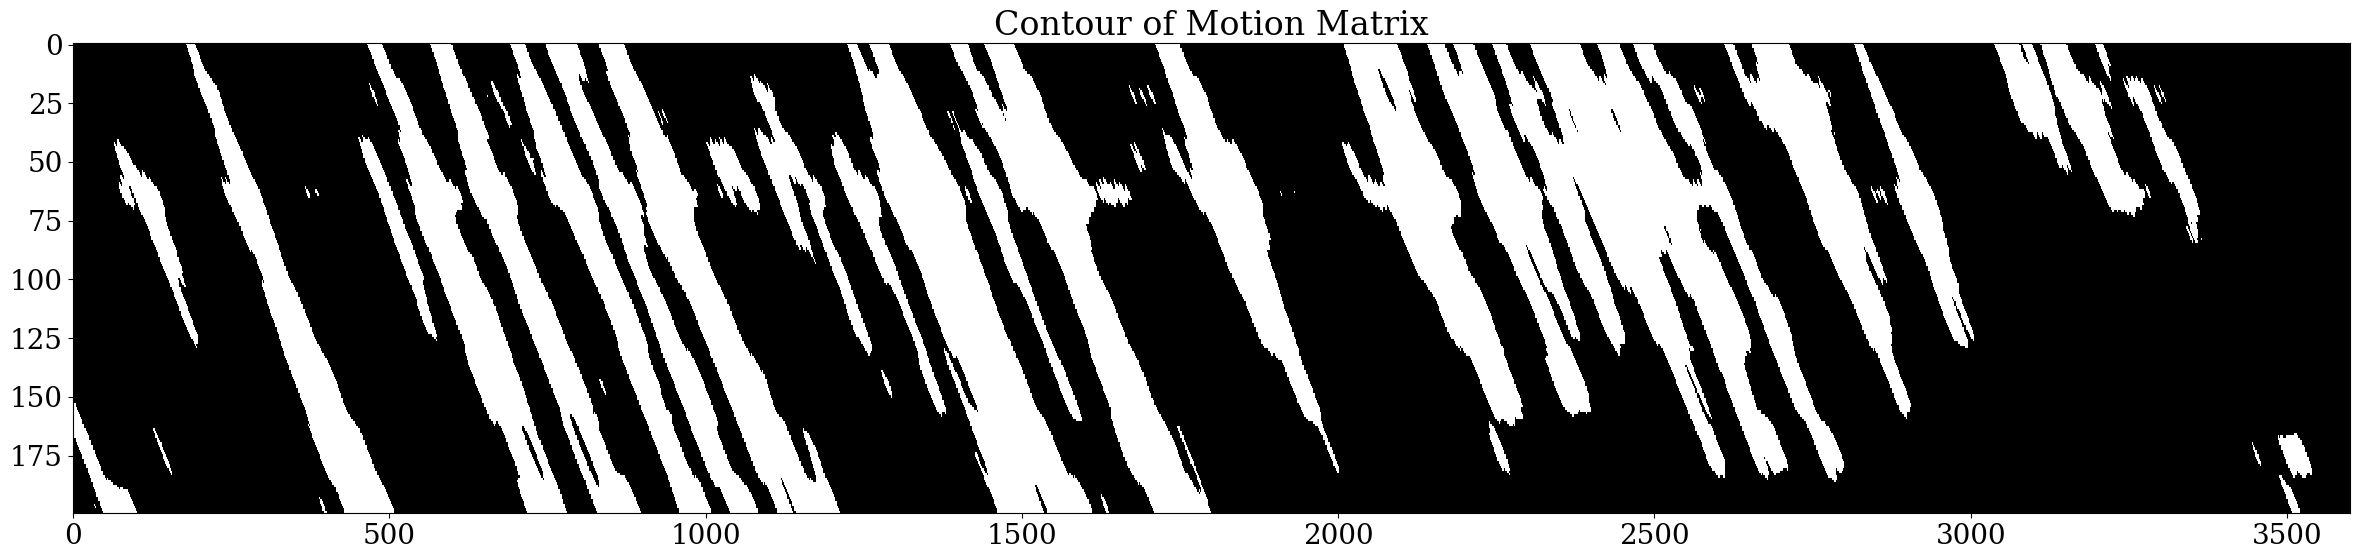

In [13]:
# visualize the contour of the matrix of motion
motion_contour = get_contour(sm,30)
plt.figure(figsize=(24, 6))
plt.rcParams.update({'font.size': 20, 'font.family': 'serif'})
plt.imshow(motion_contour, cmap='gray', interpolation='nearest', origin='lower', aspect='auto')
plt.title('Contour of Motion Matrix')
plt.tight_layout()
plt.gca().invert_yaxis()
plt.show()